In [145]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_validate, KFold
from sklearn.preprocessing import OneHotEncoder, PowerTransformer, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from joblib import dump

In [30]:
df = pd.read_csv('../data/car_predict_price.csv')

In [31]:
df

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,...,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity,Max_Power_bhp,Max_Power_rpm,Max_Torque_Nm,Max_Torque_rpm
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,...,FWD,3990.0,1680.0,1505.0,5.0,35.0,87.0,6000.0,109.0000,4500.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,...,FWD,3995.0,1695.0,1555.0,5.0,42.0,74.0,4000.0,190.0000,2000.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,...,FWD,3585.0,1595.0,1550.0,5.0,35.0,79.0,6000.0,112.7619,4000.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,...,FWD,3995.0,1745.0,1510.0,5.0,37.0,82.0,6000.0,113.0000,4200.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,...,RWD,4735.0,1830.0,1795.0,7.0,55.0,148.0,3400.0,343.0000,1400.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2054,Mahindra,XUV500 W8 [2015-2017],850000,2016,90300,Diesel,Manual,Surat,White,First,...,FWD,4585.0,1890.0,1785.0,7.0,70.0,138.0,3750.0,330.0000,1600.0
2055,Hyundai,Eon D-Lite +,275000,2014,83000,Petrol,Manual,Ahmedabad,White,Second,...,FWD,3495.0,1550.0,1500.0,5.0,32.0,55.0,5500.0,75.0000,4000.0
2056,Ford,Figo Duratec Petrol ZXI 1.2,240000,2013,73000,Petrol,Manual,Thane,Silver,First,...,FWD,3795.0,1680.0,1427.0,5.0,45.0,70.0,6250.0,102.0000,4000.0
2057,BMW,5-Series 520d Luxury Line [2017-2019],4290000,2018,60474,Diesel,Automatic,Coimbatore,White,First,...,RWD,4936.0,1868.0,1479.0,5.0,65.0,188.0,4000.0,400.0000,1750.0


---
## Preprocessing

In [32]:
X = df.drop('Price', axis=1)
y = df['Price']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

In [34]:
numeric_columns = X.select_dtypes(exclude='object').columns

In [35]:
numeric_columns

Index(['Year', 'Kilometer', 'Engine', 'Length', 'Width', 'Height',
       'Seating Capacity', 'Fuel Tank Capacity', 'Max_Power_bhp',
       'Max_Power_rpm', 'Max_Torque_Nm', 'Max_Torque_rpm'],
      dtype='object')

In [36]:
categorical_columns = X.select_dtypes(include='object').columns

In [37]:
categorical_columns

Index(['Make', 'Model', 'Fuel Type', 'Transmission', 'Location', 'Color',
       'Owner', 'Seller Type', 'Drivetrain'],
      dtype='object')

**Preprocessing for linear models**

In [38]:
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) 

In [49]:
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('robust', RobustScaler()),
    ('power_trans', PowerTransformer(method='yeo-johnson')),
])

In [50]:
preprocessor = ColumnTransformer(transformers=[
    ('num_columns', numerical_pipeline, numeric_columns),
    ('cat_columns', categorical_pipeline, categorical_columns),
])

**Preprocessing for tree based model**

In [51]:
preprocessor_tree_based_models = ColumnTransformer(transformers=[
    ('num_columns', SimpleImputer(strategy='median'), numeric_columns),
    ('cat_columns', categorical_pipeline, categorical_columns),
])

---
## Training Base Model
**This section first training models with default hyperparameters and evaluation models with MAE, RMSE and R2 and second We are training best model with GridSearchCV and find best hyperparameter**

In [52]:
def score_calc(cv):
    result = dict()
    
    cv_r2 = cv['test_r2']
    cv_mae = -cv['test_mae']
    cv_rmse = -cv['test_rmse']
    
    result['r2_mean'] = cv_r2.mean()
    result['r2_std'] = cv_r2.std()
    
    result['mae_mean'] = cv_mae.mean()
    result['mae_std'] = cv_mae.std()
    
    result['rmse_mean'] = cv_rmse.mean()
    result['rmse_std'] = cv_rmse.std()
    
    
    return result

In [53]:
def base_model_training(x_data: pd.DataFrame, y_data: pd.DataFrame, preprocessor_step, base_model) -> dict:
    errors_dict = {
        'r2': 'r2',
        'rmse': 'neg_root_mean_squared_error',
        'mae': 'neg_mean_absolute_error'
    }
    
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor_step),
        ('model', base_model)
    ])
    
    wrapped_model = TransformedTargetRegressor(
        regressor=pipe,
        func=np.log1p,
        inverse_func=np.expm1
    )

    kf = KFold(n_splits=5, shuffle=True, random_state=101)
    
    cv = cross_validate(
        estimator=wrapped_model,
        X=x_data,
        y=y_data,
        scoring=errors_dict,
        cv=kf,
    )
    
    cv_score = score_calc(cv)
    
    return cv_score

In [156]:
base_models = {
    'linear_regression': LinearRegression(),
    'elasticnet': ElasticNet(random_state=101),
    'random_forest': RandomForestRegressor(random_state=101),
    'gradient_boosting': GradientBoostingRegressor(random_state=101),
    'AdaBoost': AdaBoostRegressor(random_state=101),
    'svr': SVR(max_iter=1000000),
}

In [92]:
model_errors = dict()

for name, model in base_models.items():
    if name in ['random_forest', 'gradient_boosting', 'AdaBoost']:
        preprocessor_steps = preprocessor_tree_based_models
    else:
        preprocessor_steps = preprocessor
    
    result = base_model_training(X_train, y_train, preprocessor_steps, model)
    
    model_errors[name] = {
        'r2_mean': result['r2_mean'],
        'r2_std': result['r2_std'],
        'mae_mean': result['mae_mean'],
        'mae_std': result['mae_std'],
        'rmse_mean': result['rmse_mean'],
        'rmse_std': result['rmse_std']
    }

In [93]:
errors = pd.DataFrame(data=model_errors.values(), index=model_errors.keys())

In [94]:
errors

,r2_mean,r2_std,mae_mean,mae_std,rmse_mean,rmse_std
linear_regression,-6746.506586,13485.770022,6.490423e+06,1.124400e+07,8.077762e+07,1.539650e+08
elasticnet,0.056924,0.007134,1.038253e+06,5.515870e+04,2.337993e+06,1.948905e+05
random_forest,0.759999,0.046829,3.235816e+05,2.193542e+04,1.183093e+06,2.130514e+05
gradient_boosting,0.793825,0.072505,3.350441e+05,1.991555e+04,1.090064e+06,2.725566e+05
AdaBoost,0.672218,0.076730,5.012953e+05,3.806622e+04,1.380745e+06,2.675256e+05
svr,0.736954,0.108162,3.112551e+05,1.319411e+04,1.229325e+06,3.516555e+05


**The results clearly show that the Linear Regression model is not suitable for this dataset, producing extremely high error values compared to other algorithms. To ensure a better scale for comparison and a clearer interpretation of the well-performing models, Linear Regression has been excluded from the final error analysis and plots.**

In [95]:
errors.drop(labels=['linear_regression'], axis=0, inplace=True)

In [96]:
errors

,r2_mean,r2_std,mae_mean,mae_std,rmse_mean,rmse_std
elasticnet,0.056924,0.007134,1.038253e+06,55158.700572,2.337993e+06,194890.479438
random_forest,0.759999,0.046829,3.235816e+05,21935.420338,1.183093e+06,213051.426915
gradient_boosting,0.793825,0.072505,3.350441e+05,19915.548228,1.090064e+06,272556.602875
AdaBoost,0.672218,0.076730,5.012953e+05,38066.219104,1.380745e+06,267525.590267
svr,0.736954,0.108162,3.112551e+05,13194.114096,1.229325e+06,351655.547477


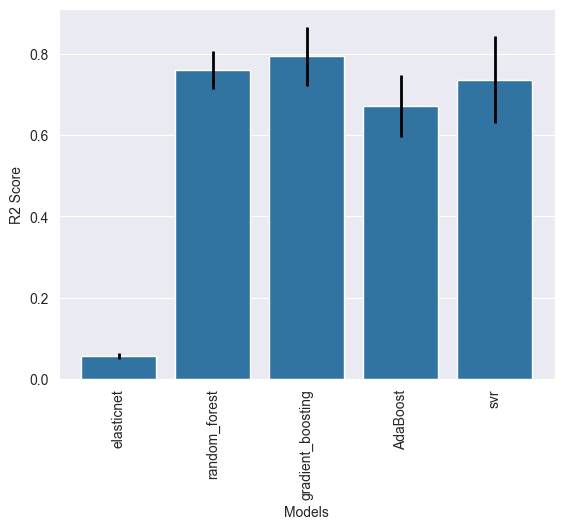

In [97]:
sns.barplot(data=errors, x=errors.index, y='r2_mean')
plt.errorbar(x=np.arange(len(errors)), y=errors['r2_mean'], yerr=errors['r2_std'], fmt='none', c='black', lw=2)
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.xticks(rotation=90);

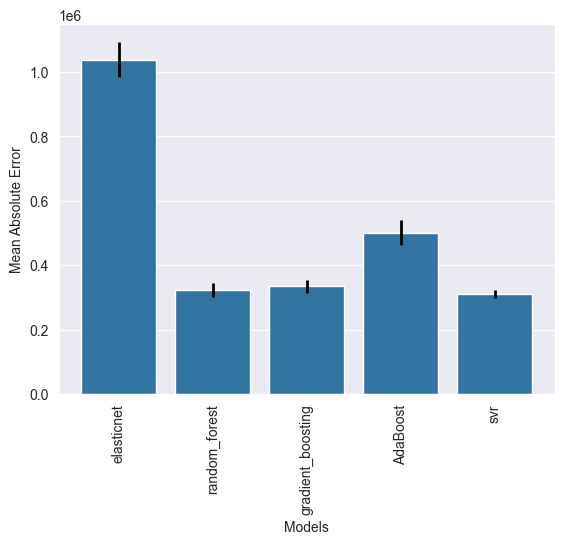

In [98]:
sns.barplot(data=errors, x=errors.index, y='mae_mean')
plt.errorbar(x=np.arange(len(errors)), y=errors['mae_mean'], yerr=errors['mae_std'], fmt='None', c='black', lw=2)
plt.xlabel("Models")
plt.ylabel("Mean Absolute Error")
plt.xticks(rotation=90);

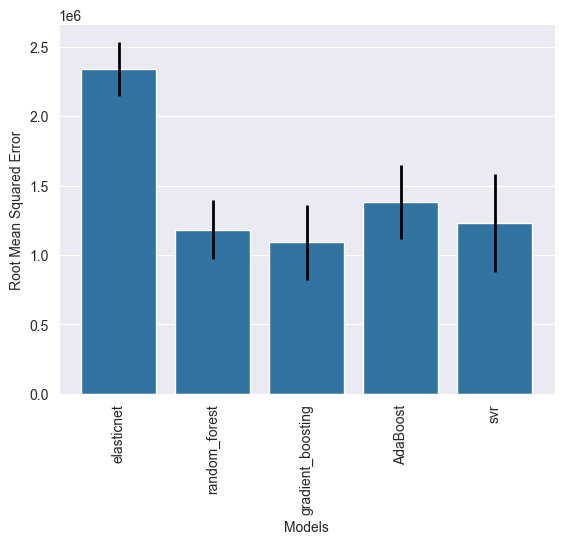

In [99]:
sns.barplot(data=errors, x=errors.index, y='rmse_mean')
plt.errorbar(x=np.arange(len(errors)), y=errors['rmse_mean'], yerr=errors['rmse_std'], c='black', fmt='None', lw=2)
plt.xlabel("Models")
plt.ylabel("Root Mean Squared Error")
plt.xticks(rotation=90);

**According to the evaluation metrics (R2 score, MAE, and RMSE), RandomForestRegressor, GradientBoostingRegressor and SVR outperformed the others. Therefore, these three models have been selected for hyperparameter tuning.**

---
## Tune Models

In [173]:
def model_tuning(tune_model, model_name, param_search, x_data, y_data, preprocessor_step):
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor_step),
        (model_name, tune_model)
    ])
    
    wrapped_model = TransformedTargetRegressor(
        regressor=pipe,
        func=np.log1p,
        inverse_func=np.expm1
    )
    
    random_search = RandomizedSearchCV(
        estimator=wrapped_model,
        param_distributions=param_search,
        scoring='neg_root_mean_squared_error',
        n_iter=30,
        cv=5,
        random_state=101,
    )
    
    random_search.fit(x_data, y_data)
    
    return random_search

In [174]:
params_search = {
    'random_forest': {
        'regressor__random_forest__n_estimators': [100, 200, 300, 400],
        'regressor__random_forest__criterion': ["squared_error", "absolute_error", "friedman_mse", "poisson"],
        'regressor__random_forest__max_depth': [None, 10, 20, 30],
        'regressor__random_forest__min_samples_split': [2, 5, 10],
        'regressor__random_forest__max_features': ["sqrt", "log2"],
        'regressor__random_forest__bootstrap': [True, False],
    },
    'gradient_boosting': {
        'regressor__gradient_boosting__n_estimators': [100, 200, 300, 400],
        'regressor__gradient_boosting__learning_rate': np.linspace(0.01, 1, 10),
        'regressor__gradient_boosting__criterion': ['friedman_mse', 'squared_error'],
        'regressor__gradient_boosting__max_depth': [None, 10, 20, 30],
        'regressor__gradient_boosting__min_samples_split': [2, 5, 10],
        'regressor__gradient_boosting__max_features': ["sqrt", "log2"],
    },
    'svr': {
        'regressor__svr__C': np.logspace(-1,1,10),
        'regressor__svr__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
        'regressor__svr__gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
        'regressor__svr__degree': [3, 4, 5, 6],
    }
}

In [175]:
tune_models = dict()
tune_score = dict()

for model_name, param in params_search.items():
    if model_name == 'svr':
        preprocessor_steps = preprocessor
    else:
        preprocessor_steps = preprocessor_tree_based_models
        
    model = model_tuning(base_models[model_name], model_name, param, X_train, y_train, preprocessor_steps)
    
    tune_models[model_name] = model
    tune_score[model_name] = -model.best_score_

In [177]:
errors_tuned = pd.DataFrame(data=tune_score.values(), index=tune_score.keys(), columns=['Tune_RMSE'])

In [178]:
errors_tuned

,Tune_RMSE
random_forest,1.287268e+06
gradient_boosting,1.202083e+06
svr,1.047669e+06


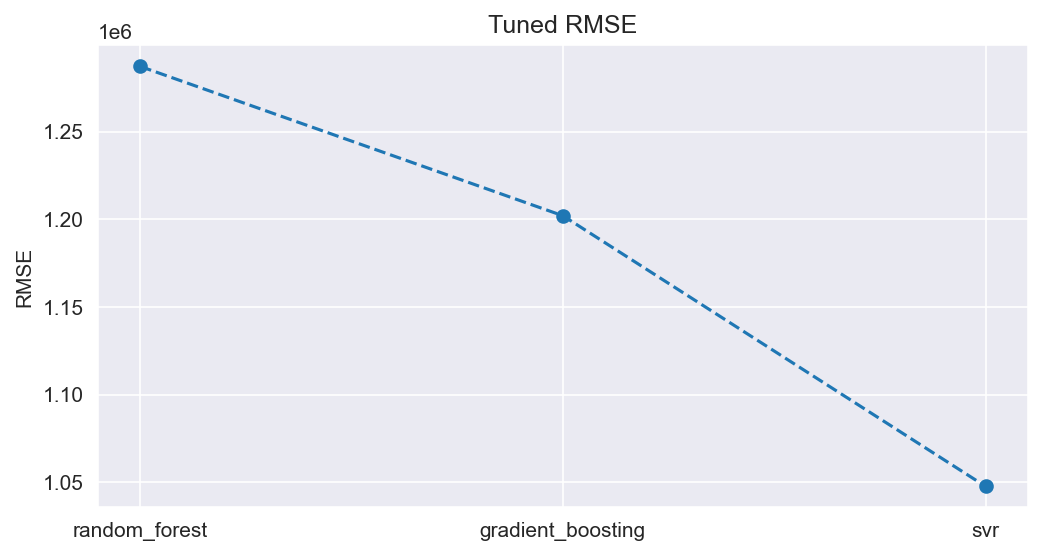

In [180]:
plt.figure(figsize=(8,4), dpi=150)
plt.plot(errors_tuned.index, errors_tuned['Tune_RMSE'], 'o--')
plt.title('Tuned RMSE')
plt.ylabel('RMSE');

**According the rmse error, we select the SVR model as the final model.**

In [181]:
best_model = tune_models.get('svr')

In [189]:
pred = best_model.predict(X_test)

In [201]:
mae = mean_absolute_error(y_test, pred)

In [202]:
rmse = np.sqrt(mean_squared_error(y_test, pred))

In [203]:
r2 = r2_score(y_test, pred)

In [207]:
mape = mean_absolute_percentage_error(y_test, pred)

In [211]:
print(f'mean absolute error: {mae}\n\
root mean squared error: {rmse}\n\
r2 score: {r2}\n\
mean absolute percentage error: {mape}')

mean absolute error: 245188.19061755016
root mean squared error: 703483.8934994731
r2 score: 0.9162243271143017
mean absolute percentage error: 0.13257586126160392


In [212]:
residual = y_test - pred

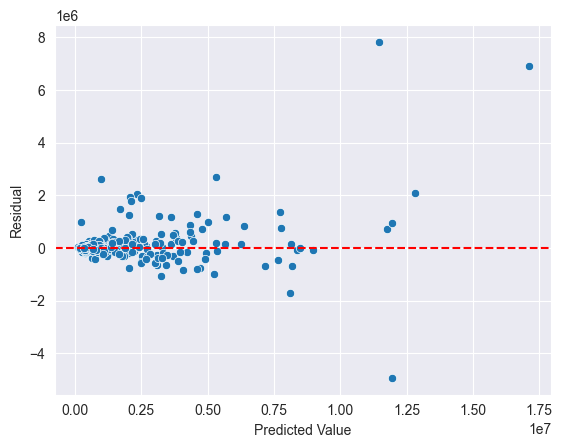

In [213]:
sns.scatterplot(x=pred, y=residual)
plt.xlabel('Predicted Value')
plt.ylabel('Residual')
plt.axhline(0, color='red', linestyle='--');

Text(0, 0.5, 'Predicted Price')

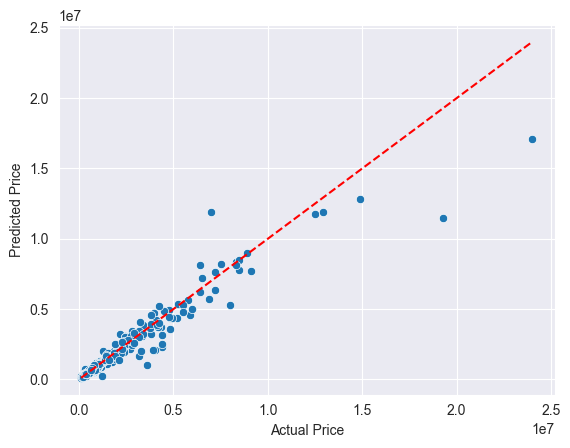

In [214]:
sns.scatterplot(x=y_test, y=pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

In [215]:
best_model.best_params_

{'regressor__svr__kernel': 'rbf',
 'regressor__svr__gamma': 0.01,
 'regressor__svr__degree': 4,
 'regressor__svr__C': np.float64(3.593813663804626)}

---
## Final model training

In [195]:
final_model = SVR(
    kernel= 'rbf',
    C= 3.593813663804626,
    gamma= 0.01,
    degree= 4,
    max_iter=500000
)

In [196]:
final_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('final_model', final_model)
])

In [197]:
final_pipe.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num_columns',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('robust',
                                                                   RobustScaler()),
                                                                  ('power_trans',
                                                                   PowerTransformer())]),
                                                  Index(['Year', 'Kilometer', 'Engine', 'Length', 'Width', 'Height',
       'Seating Capacity', 'Fuel Tank Capacity', 'Max_Power_bhp',
       'Max_Power_rpm', 'Max_Torque_Nm', '...
      dtype='object')),
                                                 ('cat_columns',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Make', 'Model', 'Fuel Type', 'Transmission', 'Location', 'Color',
       'Owner', 'Seller Type', 'Drivetrain'],
      dtype='object'))])),
                ('final_model',
                 SVR(C=3.593813663804626, degree=4, gamma=0.01,
                     max_iter=500000))])

In [217]:
dump(final_model, '../model/final_model.pkl')

['../model/final_model.pkl']